In [1]:
 %pip install "pyspark==3.5.1" faker

Note: you may need to restart the kernel to use updated packages.


In [1]:
from faker import Faker

fake = Faker()
# Установим seed, чтобы генерация была воспроизводимой (по желанию)
Faker.seed(42)

data = []
for _ in range(10):  # Сгенерируем 10 строк
    data.append({
        "name": fake.name(),
        "address": fake.address(),
        "email": fake.email(),
        "country": fake.country(),
        "random_int": fake.random_int(min=0, max=1000)
    })

data

[{'name': 'Allison Hill',
  'address': '819 Johnson Course\nEast William, AK 74064',
  'email': 'jennifermiles@example.com',
  'country': 'Cyprus',
  'random_int': 459},
 {'name': 'Rhonda Smith',
  'address': '4235 Christopher Court Suite 594\nLake Stephenville, MS 10829',
  'email': 'maria95@example.net',
  'country': 'Congo',
  'random_int': 721},
 {'name': 'Matthew Mejia',
  'address': 'Unit 3164 Box 7525\nDPO AA 27961',
  'email': 'jacqueline19@example.net',
  'country': 'Chile',
  'random_int': 546},
 {'name': 'Carla Gray',
  'address': 'Unit 8350 Box 3056\nDPO AA 09176',
  'email': 'robinbradley@example.net',
  'country': 'Germany',
  'random_int': 217},
 {'name': 'Jennifer Rocha',
  'address': '38849 Hurst Locks Suite 328\nDaviston, VI 14872',
  'email': 'courtneyconner@example.com',
  'country': 'Nepal',
  'random_int': 65},
 {'name': 'Kyle Mcdonald',
  'address': '184 Rodriguez Mews\nSouth Aaron, VA 94830',
  'email': 'teresa28@example.org',
  'country': 'Trinidad and Tobago',

In [2]:
from pyspark.sql import SparkSession
import os

os.environ["YARN_CONF_DIR"] = "/etc/hadoop/conf"
os.environ["HADOOP_USER_NAME"] = "hdfs"
os.environ["PYSPARK_PYTHON"] = "/opt/python3.10/bin/python3.10"
os.environ["PYSPARK_DRIVER_PYTHON"] = "/opt/python3.10/bin/python3.10"

spark = SparkSession.builder \
    .master("yarn") \
    .appName("PySpark Example") \
    .config("spark.eventLog.enabled", "true") \
    .config("spark.eventLog.dir", "hdfs:///var/log/spark/apps") \
    .getOrCreate()

sc = spark.sparkContext


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/04 19:56:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/04 19:56:12 WARN DomainSocketFactory: The short-circuit local reads feature cannot be used because libhadoop cannot be loaded.
26/04/04 19:56:12 WARN Client: Neither spark.yarn.jars nor spark.yarn.archive is set, falling back to uploading libraries under SPARK_HOME.


In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType
from faker import Faker

# Шаблон для схемы:
schema = StructType([
    StructField("name", StringType(), True),
    StructField("address", StringType(), True),
    StructField("email", StringType(), True),
    StructField("country", StringType(), True),
    StructField("random_int", IntegerType(), True)
])

def generate_data_in_partition(partition_index_iter):
    """
    Функция для mapPartitions.
    partition_index_iter — это итератор по индексам (или значениям), 
    которые распределены Spark в данную партицию.
    """
    fake = Faker()  # Создаем Faker внутри партиции (один на партицию)
    
    for _ in partition_index_iter:
        yield (
            fake.name(),
            fake.address(),
            fake.email(),
            fake.country(),
            fake.random_int(min=0, max=1000)
        )

# Допустим, хотим сгенерировать 1000 строк
num_rows = 50000

# Создаём RDD со значениями от 0 до 999
rdd = spark.sparkContext.range(num_rows)

# Применяем mapPartitions для генерации данных Faker
fake_rdd = rdd.mapPartitions(generate_data_in_partition)

# Конвертируем RDD в DataFrame с заданной схемой
spark_df = spark.createDataFrame(fake_rdd, schema=schema)

# Проверяем результат
spark_df.show(10, truncate=False)

+-----------------------+--------------------------------------------------------------+------------------------------+----------------------+----------+
|name                   |address                                                       |email                         |country               |random_int|
+-----------------------+--------------------------------------------------------------+------------------------------+----------------------+----------+
|Shawn Harper           |08576 Johnson Villages\nWallacebury, OH 57253                 |dominiqueblackwell@example.com|Puerto Rico           |414       |
|Christopher Odonnell MD|18597 Nancy Vista Suite 823\nRiosborough, CO 72790            |wileyrichard@example.com      |Nauru                 |154       |
|Richard Rose           |513 Catherine Valley\nJasmineborough, VI 99727                |simmonstimothy@example.org    |Bosnia and Herzegovina|487       |
|James Johnson          |68439 Jeffrey Mall Apt. 921\nAmymouth, NV 14767    

In [4]:
import random
out = f"/tmp/test_csv_{random.randint(1000,10000)}"
spark_df.write.mode("overwrite").option("header", "true").csv(out)
print(out)

[Stage 1:=============================>                             (1 + 1) / 2]

/tmp/test_csv_8536


In [5]:
spark.stop()

In [9]:
%pip install --only-binary=:all: \
  "numpy<2" \
  "pandas<2.2" \
  "scipy<1.12" \
  "scikit-learn<1.4" \
  "SQLAlchemy<2.1" \
  "matplotlib<3.9"

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 54.6 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 70.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 50.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 42.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 49.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 66.2 MB/s  0:00:00
Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 62.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63

In [10]:
!data

/bin/bash: data: command not found


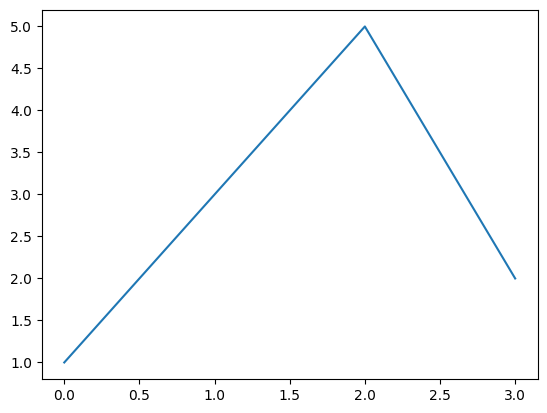

In [11]:
import matplotlib.pyplot as plt
plt.plot([1,3,5,2])

In [12]:
import numpy as np

In [13]:
np.array([1,2,3])

array([1, 2, 3])